# Random Forest: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Random Forest** in Python.

### Concept Overview
An ensemble bagging model that trains multiple independent decision trees on bootstrapped data samples.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
f(\mathbf{x}) = \text{Majority Vote} \left( h_1(\mathbf{x}), h_2(\mathbf{x}), \dots, h_B(\mathbf{x}) \right)
$$

### Real-World Analogy
**Analogy:** Asking a committee of 100 experts for advice and taking their majority vote, rather than relying on one person.

### Worked Example
**Worked Example:** Predicting loan defaults. We train 100 trees on bootstrapped versions of credit profiles. For a customer, 75 trees predict 'Default' (1) and 25 trees predict 'No Default' (0). Predict 1.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of credit default profiles
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=600, n_features=4, n_informative=3,
                                  n_redundant=1, n_classes=2, weights=[0.8, 0.2],
                                  class_sep=1.3, random_state=42)
df = pd.DataFrame({
    'CreditScore': np.round(X_raw[:, 0] * 80 + 650, 0),
    'DebtToIncome': np.round(np.clip(X_raw[:, 1] * 0.15 + 0.35, 0.05, 0.95), 2),
    'Savings': np.round(np.clip(X_raw[:, 2] * 25000 + 30000, 0, 150000), -2),
    'Age': np.round(X_raw[:, 3] * 10 + 40, 0).astype(int),
    'Default': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (600, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CreditScore   600 non-null    float64
 1   DebtToIncome  600 non-null    float64
 2   Savings       600 non-null    float64
 3   Age           600 non-null    int64  
 4   Default       600 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 23.6 KB
       CreditScore  DebtToIncome        Savings         Age     Default
count   600.000000    600.000000     600.000000  600.000000  600.000000
mean    700.513333      0.406367   12531.666667   32.021667    0.196667
std     131.919399      0.229433   21676.327391   13.566304    0.397810
min     337.000000      0.050000       0.000000    5.000000    0.000000
25%     616.000000      0.210000       0.000000   23.000000    0.000000
50%     712.500000      0.430000       0.000000   29.000000    0.000000
75%     788.0000

## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 CreditScore     0
DebtToIncome    0
Savings         0
Age             0
Default         0
dtype: int64
Duplicate count: 1


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

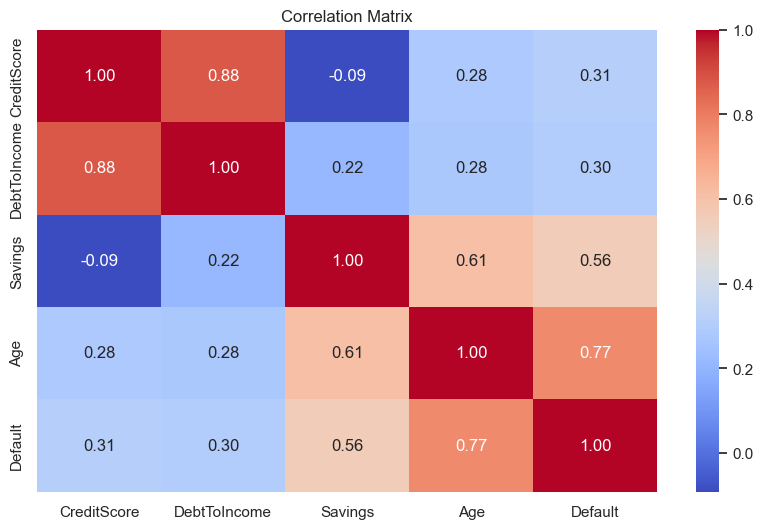

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (420, 4), Test size: (180, 4)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("ROC-AUC:", metrics.roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

Accuracy: 0.9388888888888889
ROC-AUC: 0.970230369889682
Confusion Matrix:
 [[130   4]
 [  7  39]]


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

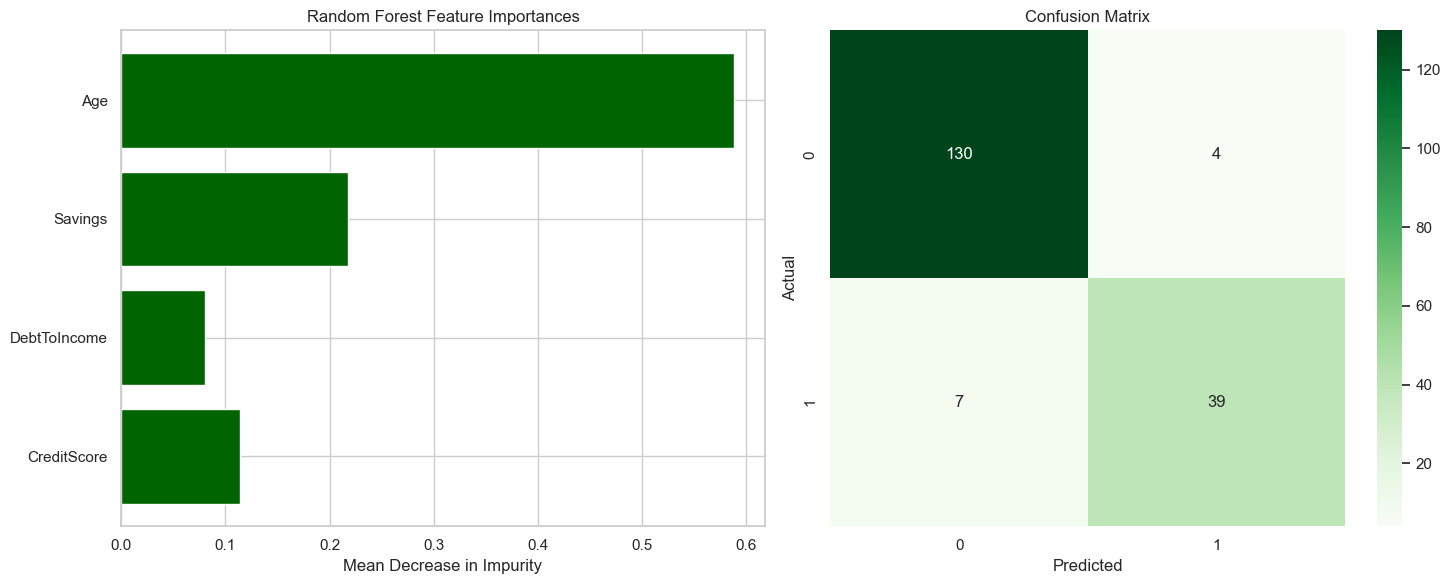

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Feature Importances
importances = model.feature_importances_
axes[0].barh(X.columns, importances, color='darkgreen')
axes[0].set_title("Random Forest Feature Importances")
axes[0].set_xlabel("Mean Decrease in Impurity")

# Plot 2: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What are the two sources of randomness in Random Forest?**

*A: 1. Bootstrap sampling (bagging): each tree is trained on a random sample of rows with replacement. 2. Feature subsetting: each split considers a random subset of columns.*

**Q2: What is Out-Of-Bag (OOB) error?**

*A: The average error evaluated on each training sample using only the trees that did not include that sample in their bootstrap training set. It serves as validation without split partition.*

**Q3: How does Random Forest reduce model variance?**

*A: By averaging the predictions of individual, highly uncorrelated decision trees (which individually have high variance).*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does the 'n_estimators' parameter do?**

*A: It sets the number of individual decision trees trained in the forest ensemble.*

**Q2: Is Random Forest prone to overfitting when n_estimators is large?**

*A: No, increasing trees count does not lead to overfitting; it simply stabilizes predictions variance.*

**Q3: Name one advantage of Random Forest over a single Decision Tree.**

*A: It has higher accuracy, generalizes much better, and is highly resistant to overfitting.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.